# Old consensus creation: Generate consensus sequence based on block structure alone

How to simplify graph to get consensus seq:
1. Deduplicate blocks: blocks that are duplicated are set into their context, the context is defined by the closest non-duplicated, non-inverted block to the left, avoid choosing rare blocks as context by setting a frequency threshold for too rare bocks, if their are repeated blocks that would get the same context and the same block id, they are distinguished by adding a number at the end marking their nth occurence with the same context
2. filter rare blocks (frequency below rare_block_threshold) by removing them from the paths
3. filter out rare edges: remove isolate paths that contain rare edges below a second threshold, remaining unique paths are consensus paths
4. Filter out consensus paths that have less than min_n_isolates isolates assigned, e.g. min_n_isolates = 5

Assign isolates to consensus paths:
- the shared edge jaccard index is calculated between each consensus path and each isolate, paths are assigned to their most similar consensus path based on this measure
- for now when filtering out rare blocks, inverted blocks are considered different from non-inverted blocks, this could be potentially changed in the future


## Build graph

In [ ]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import pypangraph as pp

from junction_analysis.plotting import plot_junction_pangraph_combined
from junction_analysis.consensus import find_consensus_paths

In [ ]:
_fname = f"../../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq,tot_acc_len
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,18953,18189.108108,218,16280.0,1698.0,False,727.5,0.018018,1488
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,12516,11742.500000,221,1529.0,10210.0,False,777.0,0.004505,777
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,29386,27955.472973,221,23708.0,4241.0,False,1437.0,0.004505,1437
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,8141,7371.000000,220,2780.0,4584.0,False,777.0,0.009009,777
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,48231,10227.959459,221,7295.0,2761.0,False,38175.0,0.004505,38175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,105312,85545.500000,0,18605.0,29023.0,False,35067.5,1.000000,70135
544,EOBHADSLFU_f__SKPHAXSFLS_r,2,1,False,1,2,False,0.000000,1,7230,7230,7230.000000,2,7230.0,7230.0,True,NaN,0.000000,0
545,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,83629,83629.000000,2,31644.0,48920.0,False,NaN,0.000000,0
546,YUOECYBHUS_f__ZTHKZYHPIX_f,2,20,True,2,1,True,0.693147,35,66709,186025,126367.000000,0,60231.0,5710.0,False,60426.0,1.000000,109823


Found 13 unique paths.
Removing rare consensus path: consensus_13 (3 isolates)
Removing rare consensus path: consensus_10 (4 isolates)


(<Figure size 1200x5368 with 1 Axes>, <Axes: xlabel='genomic position (bp)'>)

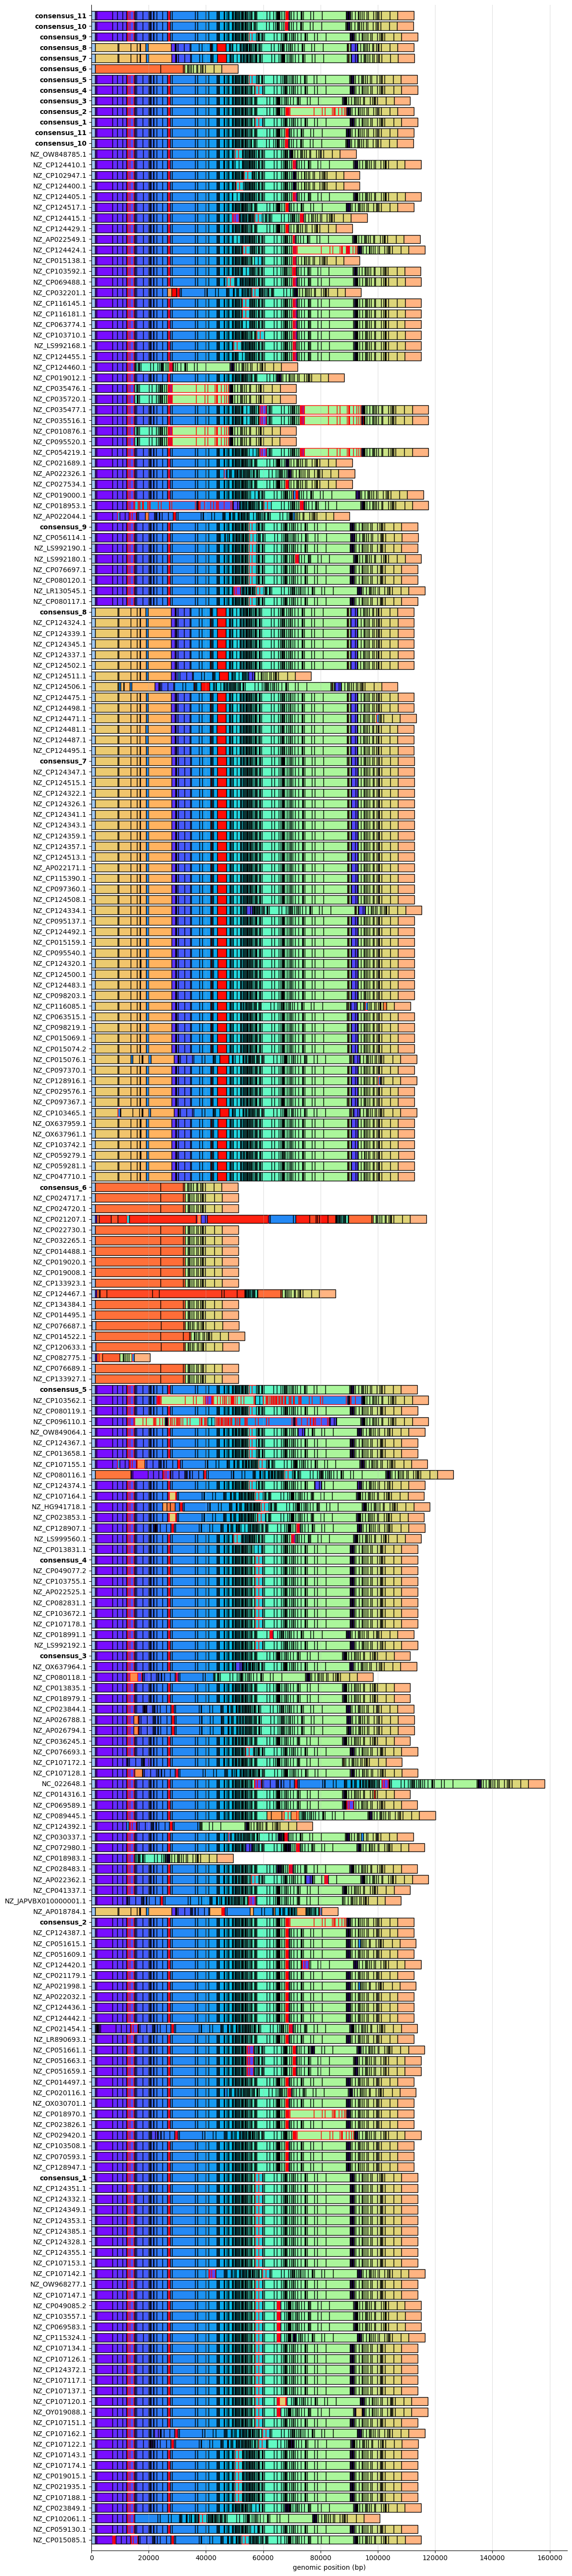

In [ ]:
example_junction = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
example_pangraph = pp.Pangraph.from_json(f"../../results/junction_pangraphs/{example_junction}.json")

consensus_paths, path_dict, _, similarity_matrix, assignment_df = find_consensus_paths(example_pangraph, rare_block_threshold=10, rare_edge_threshold=10, min_n_isolates_per_consensus=5)
#plot_junction_pangraph(example_pangraph, True, consensus_paths)
#plot_junction_pangraph_grouped(example_pangraph, consensus_paths, assignment_df)

plot_junction_pangraph_combined(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree"
)

Found 3 unique paths.


(<Figure size 1200x5016 with 1 Axes>, <Axes: xlabel='genomic position (bp)'>)

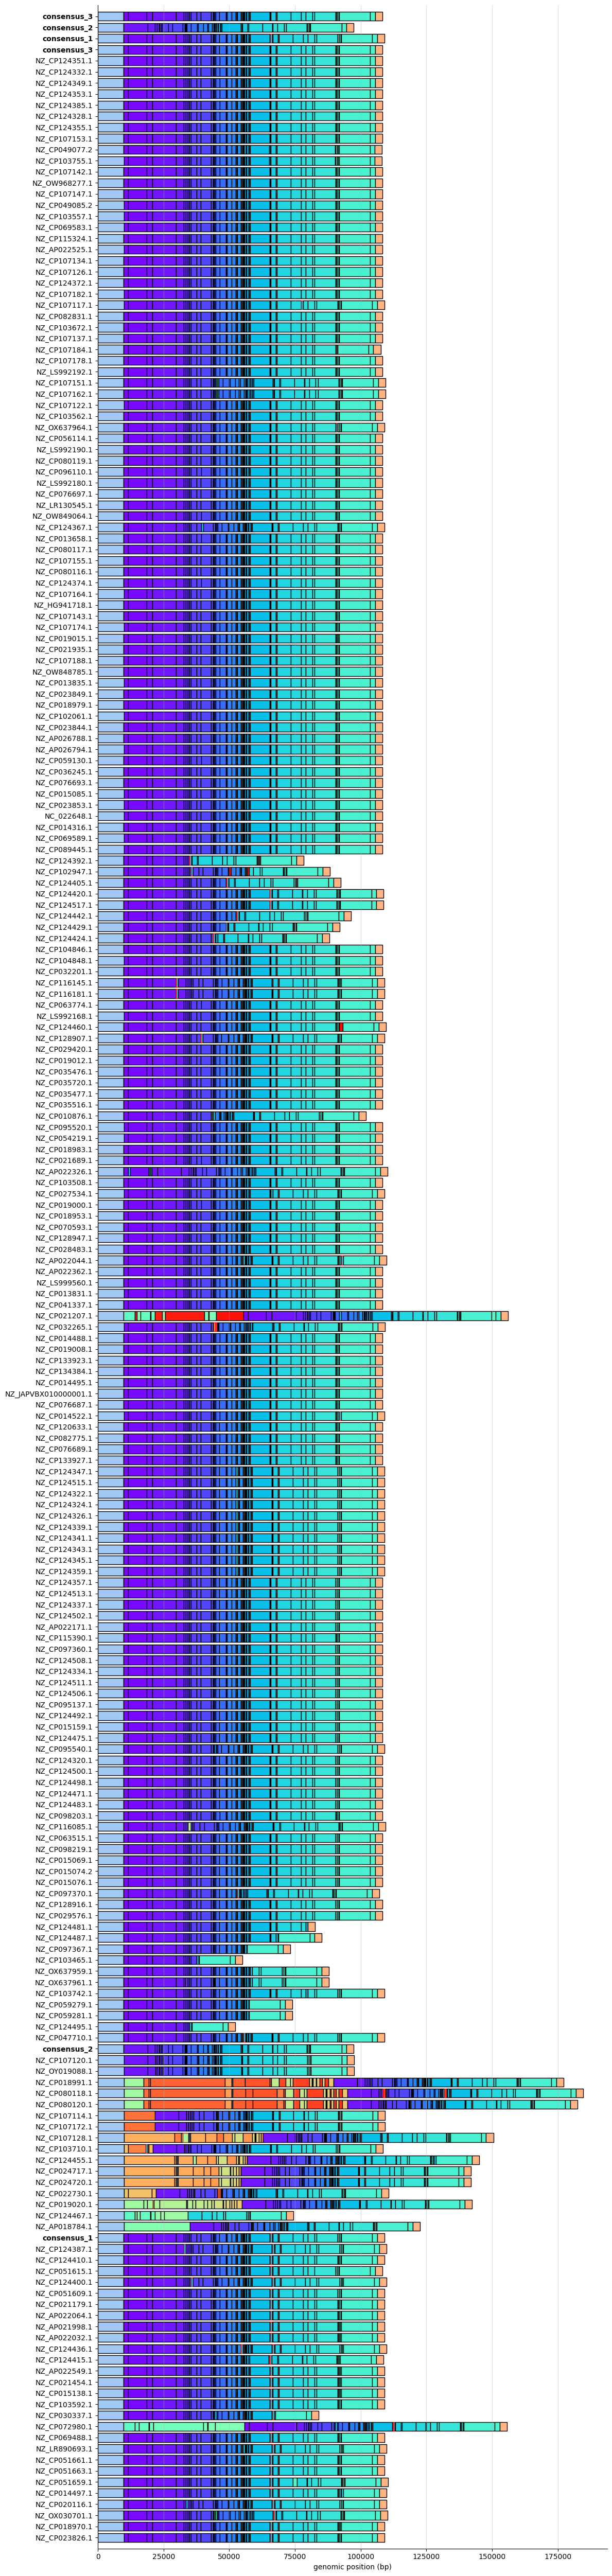

In [ ]:
example_junction = "EJPOGALASQ_f__KUIFCLFQSI_r"
example_pangraph = pp.Pangraph.from_json(f"../../results/junction_pangraphs/{example_junction}.json")

consensus_paths, path_dict, _, similarity_matrix, assignment_df = find_consensus_paths(example_pangraph, rare_block_threshold=15, rare_edge_threshold=10, min_n_isolates_per_consensus=5)

plot_junction_pangraph_combined(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree"
)

Found 3 unique paths.


(<Figure size 1200x5016 with 1 Axes>, <Axes: xlabel='genomic position (bp)'>)

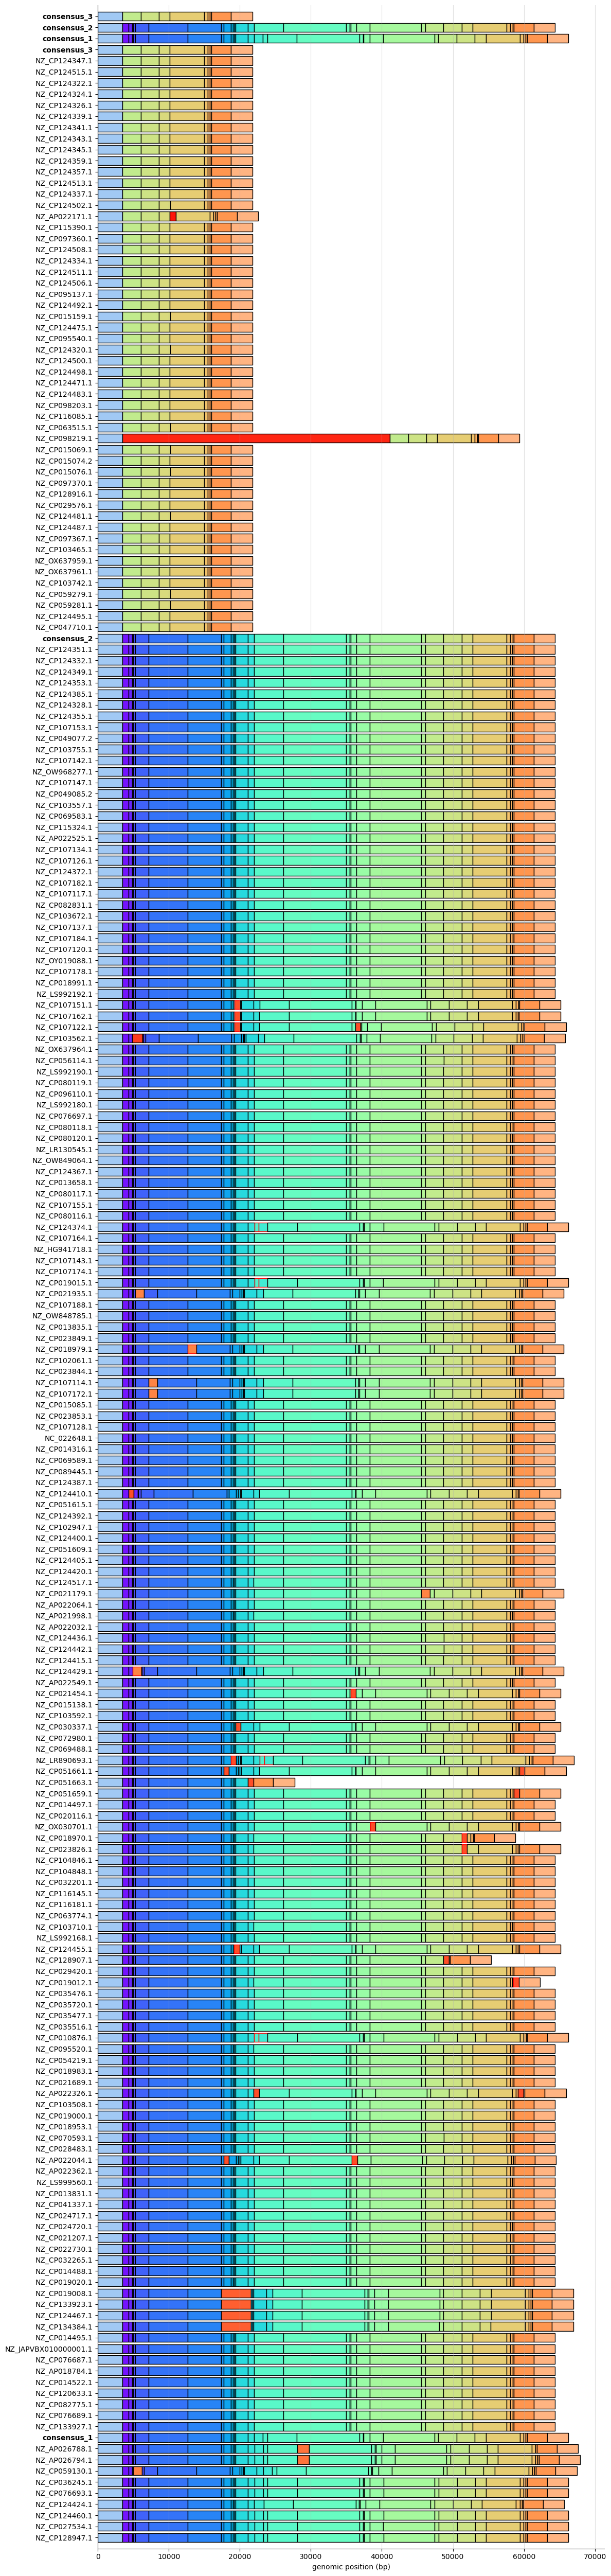

In [ ]:
example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
example_pangraph = pp.Pangraph.from_json(f"../../results/junction_pangraphs/{example_junction}.json")

consensus_paths, path_dict, _, similarity_matrix, assignment_df = find_consensus_paths(example_pangraph, rare_block_threshold=5, rare_edge_threshold=5, min_n_isolates_per_consensus=5)
plot_junction_pangraph_combined(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree"
)

Found 3 unique paths.


(<Figure size 1200x5016 with 1 Axes>, <Axes: xlabel='genomic position (bp)'>)

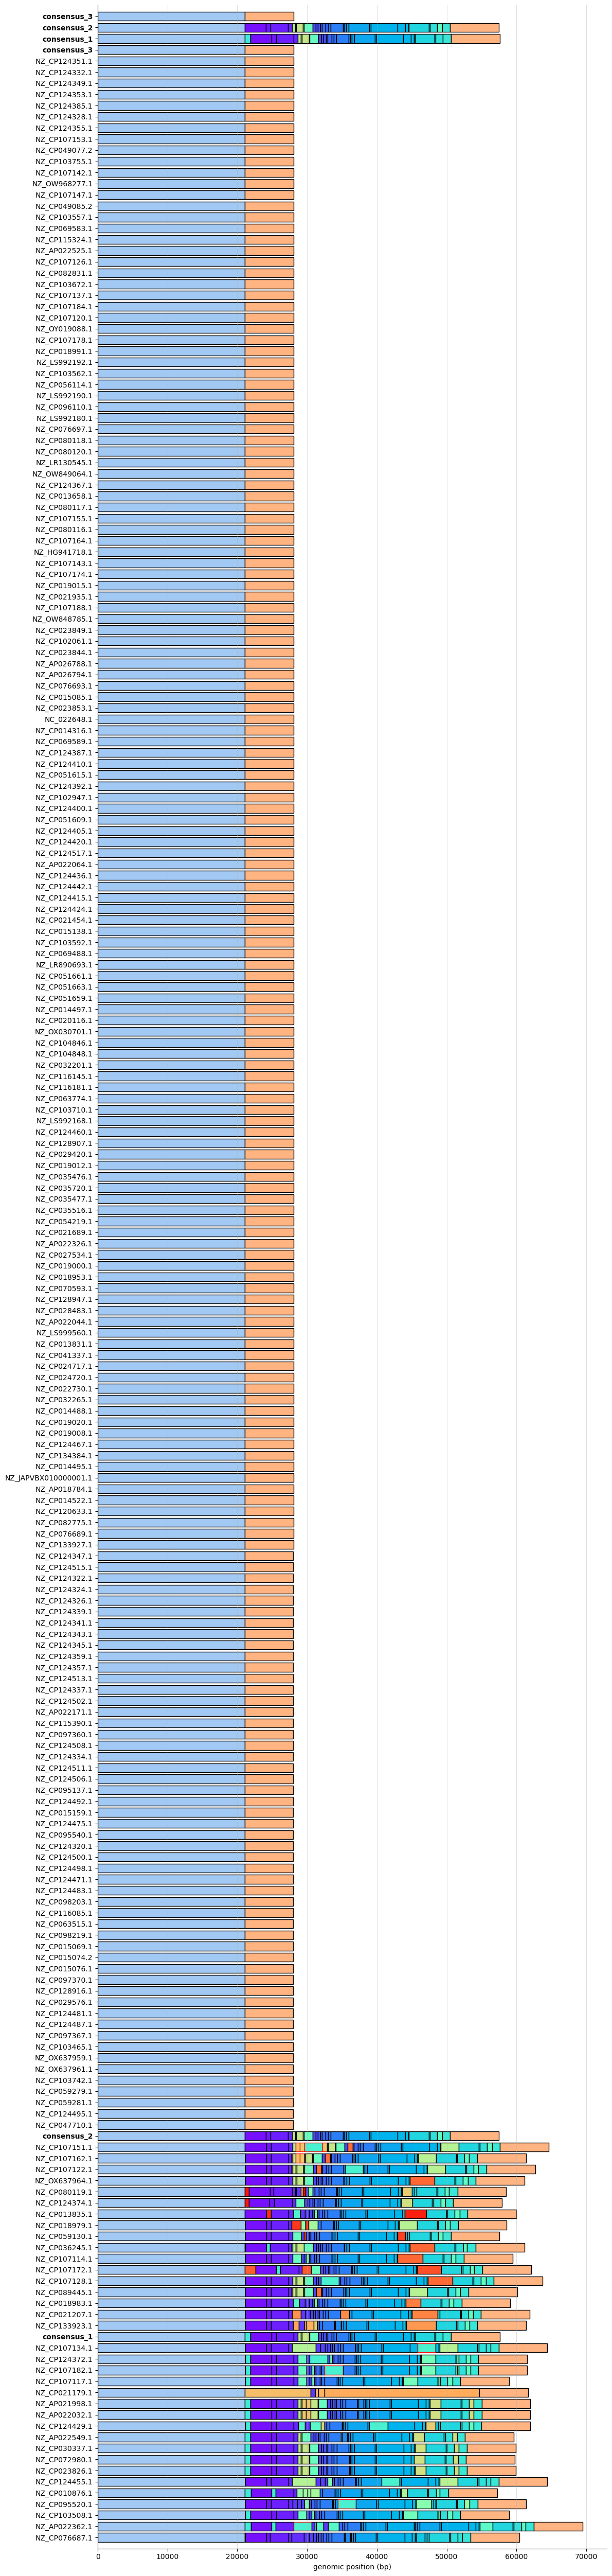

In [ ]:
example_junction = "ATPWUNKKID_f__KKPYPKGMXA_f"
example_pangraph = pp.Pangraph.from_json(f"../../results/junction_pangraphs/{example_junction}.json")

consensus_paths, path_dict, _,  similarity_matrix, assignment_df = find_consensus_paths(example_pangraph, rare_block_threshold=10, rare_edge_threshold=10, min_n_isolates_per_consensus=5)
plot_junction_pangraph_combined(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree"
)